# Code Template for Map

1. one map per figure
2. multi map per figure

## 1. one map per figure

In [210]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.colors as mcolors
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

In [211]:
# Function to create a colormap from a AR6 text file containing RGB values
def create_colormap_from_txt(filepath, cmap_name="custom_colormap"):
    """
    Read RGB values from a text file and create a LinearSegmentedColormap.
    RGB value shoud be 0-1 range.
    """
    rgb_data = np.loadtxt(filepath)
    colormap = mcolors.LinearSegmentedColormap.from_list(cmap_name, rgb_data)
    return colormap

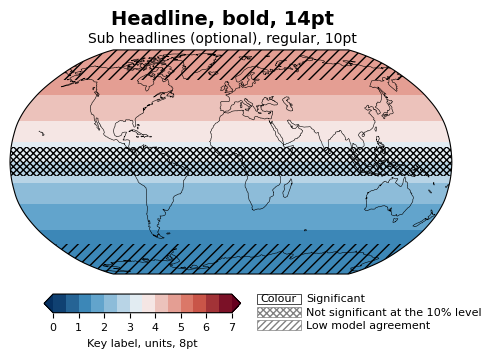

In [212]:
# Dummy data
lon = np.linspace(-180, 180, 360)
lat = np.linspace(-90, 90, 180)
lon2d, lat2d = np.meshgrid(lon, lat)

data = 3 + 2 * np.sin(np.deg2rad(lat2d))
levels = np.linspace(0, 7, 15)

# Dummy significance mask
no_significance = np.abs(lat2d) <10
low_model_agreement = np.abs(lat2d) >60


# Figure layout
fig = plt.figure(figsize=(6.5, 3.65))

gs = gridspec.GridSpec(
    nrows=2,
    ncols=2,
    height_ratios=[12, 2],  # 12 top row for map, 1 bottom row for legend and colorbar
    width_ratios=[1, 1],
    hspace=0.15,
    wspace=0.05
)

 
# Headings
fig.text(0.5, 0.95,
         "Headline, bold, 14pt",
         ha='center',
         fontsize=14,
         fontweight='bold')

fig.text(
    0.5, 0.90,
    "Sub headlines (optional), regular, 10pt",
    ha='center',
    fontsize=10,
)

 
# Map axis
ax = fig.add_subplot(gs[0, :], projection=ccrs.Robinson()) # Robinson projection is IPCC standard for global maps
ax.set_global()

cmap = create_colormap_from_txt("./continuous_colormaps_rgb_0-1/temp_div.txt")

 
# Colour layer
im = ax.contourf(
    lon, lat, data,
    levels=levels,
    cmap=cmap,
    transform=ccrs.PlateCarree(),
    extend='both',
    zorder=1
)

# Diagonal hatching
ax.contourf(
    lon, lat, no_significance,
    levels=[0.5, 1],
    hatches=['xxxxx'],
    colors='none',
    transform=ccrs.PlateCarree(),
    zorder=2
)

ax.contourf(
    lon, lat, low_model_agreement,
    levels=[0.5, 1],
    hatches=['///'],
    colors='none',
    transform=ccrs.PlateCarree(),
    zorder=2
)

 
# Coastlines
ax.coastlines(linewidth=0.4, zorder=5) # miminum linewidth for coastlines is 0.09mm (0.255 pt)

 
# Bottom Left: Colourbar (50%)

# create a custom axis for the colorbar in the bottom left cell of the grid
cax = fig.add_subplot(gs[1, 0])
pos = cax.get_position()  # Bbox: [x0, y0, width, height]

# modify position to make the colorbar thinner and shift right
new_pos = [pos.x0 + 0.1,   # move right
           pos.y0 + 0.05,  # move up slightly
           pos.width * 0.8, # shrink width
           pos.height * 0.5] # reduce height to make it thinner

cax.set_position(new_pos)

# create the colorbar in the custom axis
cbar = plt.colorbar(
    im,
    cax=cax,
    orientation='horizontal',
)

cbar.set_label("Key label, units, 8pt", fontsize=8)
cbar.ax.tick_params(labelsize=8)


# Bottom right (50%): Custom Legend
lax = fig.add_subplot(gs[1, 1])
lax.axis('off')

legend_loc_x = 0.1
legend_loc_y = 0.75
legend_loc_spacing = 0.35

box_size_x = 0.14
box_size_y = 0.22
box_linewidth = 0.5

# 1. Significant: white box with "Colour" text
sig_box = mpatches.FancyBboxPatch(
    (legend_loc_x, legend_loc_y), box_size_x, box_size_y,
    boxstyle="square,pad=0.02",
    facecolor='white',
    edgecolor='black',
    linewidth=box_linewidth
)

lax.add_patch(sig_box)
lax.text(legend_loc_x + box_size_x/2, legend_loc_y + box_size_y/2, 
         "Colour",
         ha='center', va='center',
         fontsize=8)


# 2. Not significant: white box with X hatch
nonsig_box = mpatches.FancyBboxPatch(
    (legend_loc_x, legend_loc_y - legend_loc_spacing), box_size_x, box_size_y,
    boxstyle="square,pad=0.02",
    facecolor='white',
    edgecolor='gray',
    hatch='xxxxx',
    linewidth=box_linewidth
)

lax.add_patch(nonsig_box)

# 3. Low model agreement: white box with / hatch
lowagree_box = mpatches.FancyBboxPatch(
    (legend_loc_x, legend_loc_y - 2*legend_loc_spacing), box_size_x, box_size_y,
    boxstyle="square,pad=0.02",
    facecolor='white',
    edgecolor='gray',
    hatch='/////',
    linewidth=box_linewidth
)

lax.add_patch(lowagree_box)

# add text labels for the legend
lax.text(0.4, legend_loc_y + box_size_y/2, 
         "Significant",
         ha='center', va='center',
         fontsize=8)

lax.text(0.28, legend_loc_y - legend_loc_spacing + box_size_y/2,
         "Not significant at the 10% level",
         va='center',
         fontsize=8)

lax.text(0.28, legend_loc_y - 2*legend_loc_spacing + box_size_y/2,
         "Low model agreement",
         va='center',
         fontsize=8)

 
# Save and show
plt.savefig("fig_1map.svg", bbox_inches='tight')
plt.show()
plt.close()


## 2. multi maps per figure

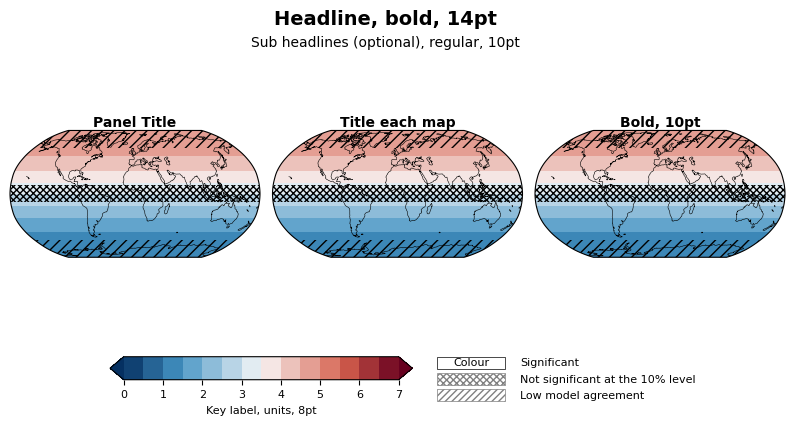

In [213]:
# Dummy data
lon = np.linspace(-180, 180, 360)
lat = np.linspace(-90, 90, 180)
lon2d, lat2d = np.meshgrid(lon, lat)

data = 3 + 2 * np.sin(np.deg2rad(lat2d))
levels = np.linspace(0, 7, 15)

# Dummy significance mask
no_significance = np.abs(lat2d) < 10
low_model_agreement = np.abs(lat2d) > 60


# Figure layout
fig = plt.figure(figsize=(10, 4.5))  # wider to fit 3 panels

gs = gridspec.GridSpec(
    nrows=2,
    ncols=3,
    height_ratios=[12, 2],   # maps + bottom row
    hspace=0.15,
    wspace=0.05
)

# Create a nested GridSpec for the bottom row to hold the colorbar and legend
bottom_gs = gridspec.GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=gs[1, :],
    wspace=0.05
)

# Headings
fig.text(0.5, 0.95,
         "Headline, bold, 14pt",
         ha='center',
         fontsize=14,
         fontweight='bold')

fig.text(
    0.5, 0.90,
    "Sub headlines (optional), regular, 10pt",
    ha='center',
    fontsize=10,
)


# Colormap
cmap = create_colormap_from_txt("./continuous_colormaps_rgb_0-1/temp_div.txt")


# ---- THREE MAP PANELS ----
axes = []
for i in range(3):
    ax = fig.add_subplot(gs[0, i], projection=ccrs.Robinson())
    ax.set_global()

    im = ax.contourf(
        lon, lat, data,
        levels=levels,
        cmap=cmap,
        transform=ccrs.PlateCarree(),
        extend='both',
        zorder=1
    )

    # Hatching overlays
    ax.contourf(
        lon, lat, no_significance,
        levels=[0.5, 1],
        hatches=['xxxxx'],
        colors='none',
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    ax.contourf(
        lon, lat, low_model_agreement,
        levels=[0.5, 1],
        hatches=['///'],
        colors='none',
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    ax.coastlines(linewidth=0.4, zorder=5)

    # Panel titles
    panel_titles = ["Panel Title", "Title each map", "Bold, 10pt"]
    ax.set_title(panel_titles[i], fontsize=10, fontweight='bold', pad=3)

    axes.append(ax)


# ---- Bottom Left: Colourbar (spanning first two columns) ----
cax = fig.add_subplot(bottom_gs[0, 0])
pos = cax.get_position()

new_pos = [pos.x0 + 0.1,
           pos.y0 + 0.05,
           pos.width * 0.8,
           pos.height * 0.5]

cax.set_position(new_pos)

cbar = plt.colorbar(
    im,
    cax=cax,
    orientation='horizontal',
)

cbar.set_label("Key label, units, 8pt", fontsize=8)
cbar.ax.tick_params(labelsize=8)


# ---- Bottom Right: Custom Legend ----
lax = fig.add_subplot(bottom_gs[0, 1])
lax.axis('off')

legend_loc_x = 0.1
legend_loc_y = 0.75
legend_loc_spacing = 0.35

box_size_x = 0.14
box_size_y = 0.22
box_linewidth = 0.5

# 1. Significant
sig_box = mpatches.FancyBboxPatch(
    (legend_loc_x, legend_loc_y), box_size_x, box_size_y,
    boxstyle="square,pad=0.02",
    facecolor='white',
    edgecolor='black',
    linewidth=box_linewidth
)
lax.add_patch(sig_box)

lax.text(legend_loc_x + box_size_x/2,
         legend_loc_y + box_size_y/2,
         "Colour",
         ha='center', va='center',
         fontsize=8)

# 2. Not significant
nonsig_box = mpatches.FancyBboxPatch(
    (legend_loc_x, legend_loc_y - legend_loc_spacing),
    box_size_x, box_size_y,
    boxstyle="square,pad=0.02",
    facecolor='white',
    edgecolor='gray',
    hatch='xxxxx',
    linewidth=box_linewidth
)
lax.add_patch(nonsig_box)

# 3. Low model agreement
lowagree_box = mpatches.FancyBboxPatch(
    (legend_loc_x, legend_loc_y - 2*legend_loc_spacing),
    box_size_x, box_size_y,
    boxstyle="square,pad=0.02",
    facecolor='white',
    edgecolor='gray',
    hatch='/////',
    linewidth=box_linewidth
)
lax.add_patch(lowagree_box)

# Legend text
lax.text(0.3, legend_loc_y + box_size_y/2,
         "Significant",
         ha='left', va='center',
         fontsize=8)

lax.text(0.3, legend_loc_y - legend_loc_spacing + box_size_y/2,
         "Not significant at the 10% level",
         ha='left', va='center',
         fontsize=8)

lax.text(0.3, legend_loc_y - 2*legend_loc_spacing + box_size_y/2,
         "Low model agreement",
         ha='left', va='center',
         fontsize=8)


# Save and show
plt.savefig("fig_3panel.svg", bbox_inches='tight')
plt.show()
plt.close()


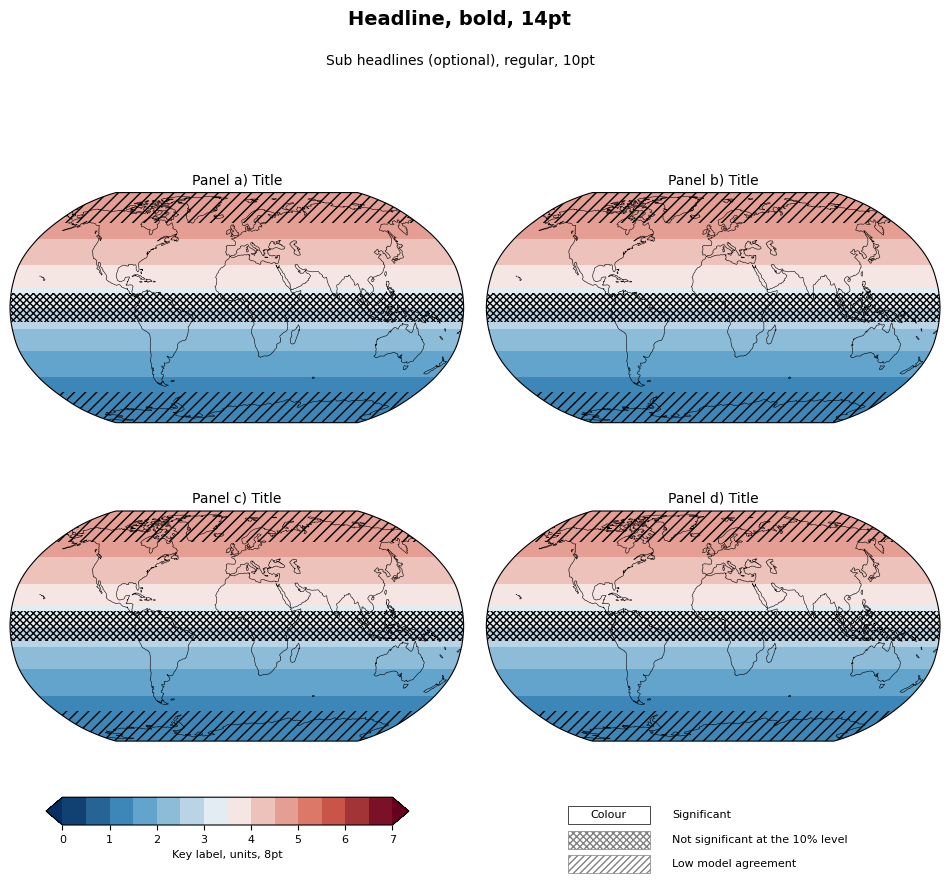

In [214]:
fig = plt.figure(figsize=(12, 10))  # wider to fit 2x2 maps nicely

# GridSpec: 4 rows, 2 columns
gs = gridspec.GridSpec(
    nrows=4,
    ncols=2,
    height_ratios=[1, 12, 12, 3],  # title, maps row1, maps row2, bottom
    hspace=0.25,
    wspace=0.05
)

# ---- Figure title ----
fig.text(0.5, 0.96,
         "Headline, bold, 14pt",
         ha='center', fontsize=14, fontweight='bold')
fig.text(0.5, 0.92,
         "Sub headlines (optional), regular, 10pt",
         ha='center', fontsize=10)

# ---- Maps ----
cmap = create_colormap_from_txt("./continuous_colormaps_rgb_0-1/temp_div.txt")

axes = []
for i in range(4):
    row = 1 + i // 2  # maps start at row 1
    col = i % 2
    ax = fig.add_subplot(gs[row, col], projection=ccrs.Robinson())
    ax.set_global()

    im = ax.contourf(
        lon, lat, data,
        levels=levels,
        cmap=cmap,
        transform=ccrs.PlateCarree(),
        extend='both',
        zorder=1
    )

    # Hatching for significance
    ax.contourf(
        lon, lat, no_significance,
        levels=[0.5, 1],
        hatches=['xxxxx'],
        colors='none',
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    ax.contourf(
        lon, lat, low_model_agreement,
        levels=[0.5, 1],
        hatches=['///'],
        colors='none',
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    ax.coastlines(linewidth=0.4, zorder=5)
    ax.set_title(f"Panel {chr(97+i)}) Title", fontsize=10)
    axes.append(ax)

# ---- Bottom row: colorbar and legend ----
# Left: colorbar
cax = fig.add_subplot(gs[3, 0])
cbar = plt.colorbar(im, cax=cax, orientation='horizontal')

# Make the colorbar thinner and adjust vertical position
pos = cax.get_position()  # original position
new_pos = [pos.x0 + 0.03,  # move right slightly
           pos.y0 + 0.05,  # move up slightly
           pos.width * 0.8,    # shrink width to 80%
           pos.height * 0.4]  # reduce height to 40%
cax.set_position(new_pos)

cbar.set_label("Key label, units, 8pt", fontsize=8)
cbar.ax.tick_params(labelsize=8)

# Right: legend
lax = fig.add_subplot(gs[3, 1])
lax.axis('off')

legend_loc_x = 0.2
legend_loc_y = 0.75
legend_loc_spacing = 0.35
box_size_x = 0.14
box_size_y = 0.22
box_linewidth = 0.5

# 1. Significant
sig_box = mpatches.FancyBboxPatch(
    (legend_loc_x, legend_loc_y),
    box_size_x, box_size_y,
    boxstyle="square,pad=0.02",
    facecolor='white',
    edgecolor='black',
    linewidth=box_linewidth
)
lax.add_patch(sig_box)
lax.text(legend_loc_x + box_size_x/2,
         legend_loc_y + box_size_y/2,
         "Colour",
         ha='center', va='center', fontsize=8)

# 2. Not significant
nonsig_box = mpatches.FancyBboxPatch(
    (legend_loc_x, legend_loc_y - legend_loc_spacing),
    box_size_x, box_size_y,
    boxstyle="square,pad=0.02",
    facecolor='white',
    edgecolor='gray',
    hatch='xxxxx',
    linewidth=box_linewidth
)
lax.add_patch(nonsig_box)

# 3. Low model agreement
lowagree_box = mpatches.FancyBboxPatch(
    (legend_loc_x, legend_loc_y - 2*legend_loc_spacing),
    box_size_x, box_size_y,
    boxstyle="square,pad=0.02",
    facecolor='white',
    edgecolor='gray',
    hatch='/////',
    linewidth=box_linewidth
)
lax.add_patch(lowagree_box)

# Legend text
lax.text(legend_loc_x + box_size_x*1.5, legend_loc_y + box_size_y/2,
         "Significant", ha='left', va='center', fontsize=8)
lax.text(legend_loc_x + box_size_x*1.5,
         legend_loc_y - legend_loc_spacing + box_size_y/2,
         "Not significant at the 10% level", ha='left', va='center', fontsize=8)
lax.text(legend_loc_x + box_size_x*1.5,
         legend_loc_y - 2*legend_loc_spacing + box_size_y/2,
         "Low model agreement", ha='left', va='center', fontsize=8)

# ---- Save & show ----
plt.savefig("fig_4panel.svg", bbox_inches='tight')
plt.show()
plt.close()
